# H-CAST Current-Run Trade-Off Plots

Run matrix: the native H-CAST baseline, the no-global-KL baseline, coarse-first
and fine-first explicit lexicographic training, and the HCC arm. HCC is a binary on/off switch
with no onset, alpha, or temperature schedule, so it contributes one arm rather
than a grid.

HCC activation is still verified from the logged `proj_constraint_alpha` rather
than inferred from directory names: the summary reports the first active logged
epoch and the HCC alpha stored in the selected checkpoint's test metrics, which
for a binary switch should read as active from epoch 0 in every seed.

H-CAST lex runs disable global KL on all datasets, so their deltas from the
native baseline are descriptive rather than single-variable effects; the
`Baseline no_kl` arm is included as a comparison bar precisely so the global-KL
contribution can be read off separately. The HCC arm starts from the plain
baseline config on every dataset and keeps global KL, so its delta from the
native baseline does isolate HCC.

FPA, weighted AP, and level accuracy are higher-is-better; TICE and AHD are
lower-is-better. Points, bars, and error bars are mean +/- sample standard
deviation across training seeds. A trailing `*` marks a run whose
`test_metrics.yaml` predates the top-down/independent selection split, so its
checkpoint was chosen by a single criterion.

### Selection and metric family

Every figure and table below reads the **independently selected** checkpoint and
the independent metric family. Top-down decoding is deliberately not offered:
its predicted path is consistent by construction, so `tice_topdown` is exactly
`0.0` in all 194 completed seed directories under `/scratch/g.saggini1/outputs`
(checked 2026-08-05) and `fpa_topdown` equals top-down fine accuracy exactly,
which leaves a top-down trade-off view with nothing to show.

### Figure format

Figures are authored at their final printed size (6.3 in, an A4 text block with
2.5 cm margins) in the same style as `analysis/datasets_analysis.ipynb`, and are
written to `FIGURE_DIR` as PDF and PNG. Include them with `width=\linewidth`
and no further scaling: any resizing in LaTeX shrinks the fonts along with the
artwork. Figure titles are omitted on purpose — they belong in the caption.

One dataset per row rather than three panels side by side: at 6.3 in a 1x3 row
leaves about 2 in per panel, which is not enough for the direct labels or for
grouped bars once a run matrix grows.

In [1]:
from pathlib import Path
import sys

# The helper lives in notebooks/utils; also look upward so the notebook works
# when the kernel starts at the repository root.
SEARCH_PATHS = [Path.cwd(), *(parent / 'notebooks' / 'utils' for parent in (Path.cwd(), *Path.cwd().parents))]
HELPER_DIR = next((path for path in SEARCH_PATHS if (path / 'current_run_plot_utils.py').is_file()), None)
if HELPER_DIR is None:
    raise FileNotFoundError('Run this notebook from the repository tree so notebooks/utils is discoverable.')
sys.path.insert(0, str(HELPER_DIR))

import matplotlib.pyplot as plt

from current_run_plot_utils import (
    MECHANISM_COLORS,
    VARIANT_MARKERS,
    check_encoding,
    discover_rows,
    encode_rows,
    model_reference_specs,
    plot_level_accuracy_deltas,
    plot_tradeoff,
    print_availability,
    print_reference_availability,
    print_summary,
    use_paper_style,
)

use_paper_style()

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
# Each figure is written as a PDF and a PNG at its authored printed size.
SAVE_FIGURES = True
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'current_runs' / 'hcast'

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

In [2]:
RUN_SPECS = [
    {'key': 'baseline', 'label': 'Baseline',
     'mechanism': 'baseline', 'variant': 'native', 'canonical': True,
     'run_name': 'hcast_{dataset}'},
    # An ablation of the baseline rather than a different intervention, so it
    # keeps the baseline colour and separates on shape.
    {'key': 'baseline_nokl', 'label': 'Baseline no_kl',
     'mechanism': 'baseline', 'variant': 'no_global_kl',
     'run_name': 'hcast_{dataset}_nokl'},
    {'key': 'lex_coarse_first', 'label': 'Lex coarse-first',
     'mechanism': 'lex', 'variant': 'coarse_first',
     'run_name': 'hcast_{dataset}_lex_coarse_first'},
    {'key': 'lex_fine_first', 'label': 'Lex fine-first',
     'mechanism': 'lex', 'variant': 'fine_first',
     'run_name': 'hcast_{dataset}_lex_fine_first'},
    # HCC is a binary on/off switch with no onset schedule, so it contributes a
    # single arm. scripts/hcast/run_hcast_hcc.sh starts from the plain baseline
    # config on every dataset, which keeps global KL on and makes this a
    # single-variable change from the native baseline.
    {'key': 'hcc', 'label': 'HCC',
     'mechanism': 'hcc', 'variant': 'hcc_on',
     'run_name': 'hcast_{dataset}_hcc'},
]

REFERENCE_SPECS = model_reference_specs(exclude={'hcast'})

In [3]:
rows, missing_runs = discover_rows(OUTPUTS_ROOT, DATASETS, RUN_SPECS)
reference_rows, missing_references = discover_rows(
    OUTPUTS_ROOT, DATASETS, REFERENCE_SPECS, pareto=False
)

# Colour encodes the mechanism and means the same thing in every model's
# notebook; shape separates the variants within a mechanism.
ENCODING = encode_rows(
    rows,
    hue=('mechanism', MECHANISM_COLORS),
    shape=('variant', VARIANT_MARKERS),
)

print_availability(rows, missing_runs, DATASETS)
print_reference_availability(reference_rows, missing_references, DATASETS)
check_encoding(rows, reference_rows, DATASETS)


CIFAR-100 runs
  Baseline                    3 seed(s): hcast_cifar100
  Lex coarse-first            3 seed(s): hcast_cifar100_lex_coarse_first
  HCC                         3 seed(s): hcast_cifar100_hcc
  Baseline no_kl             missing: hcast_cifar100_nokl
  Lex fine-first             missing: hcast_cifar100_lex_fine_first

CUB-200 runs
  Baseline                    3 seed(s): hcast_cub200
  Lex coarse-first            3 seed(s): hcast_cub200_lex_coarse_first
  HCC                         3 seed(s): hcast_cub200_hcc
  Baseline no_kl             missing: hcast_cub200_nokl
  Lex fine-first             missing: hcast_cub200_lex_fine_first

Aircraft runs
  Baseline                    3 seed(s): hcast_aircraft
  Lex coarse-first            3 seed(s): hcast_aircraft_lex_coarse_first
  HCC                         3 seed(s): hcast_aircraft_hcc
  Baseline no_kl             missing: hcast_aircraft_nokl
  Lex fine-first             missing: hcast_aircraft_lex_fine_first

CIFAR-100 reference

[]

## FPA Trade-Off

Each panel shows the individual seeds, the across-seed mean, a
one-standard-deviation covariance ellipse when at least three seeds are
available, and a thin crosshair through the canonical baseline so every other
run reads as above/below and left/right of it.

Cross-model references (the other four model families) use the off-scale
representation: the axis range is frozen on the H-CAST runs alone, and a
reference outside that range is pinned into a shaded gutter, keeping its own
marker shape and gaining a small arrow that points toward the true value. Its
label reports the actual numbers, because the pinned position deliberately is
not one. When a dataset panel holds fewer than two H-CAST runs there is no range
to freeze on, so that panel falls back to a single shared scale.

Reference models were trained with their own recipes and epoch budgets. They are
context for the achievable operating region, not weight-matched or
schedule-matched comparisons, and they are excluded from the Pareto analysis.

### Point encoding

Colour encodes the **mechanism** — the intervention a run applies — and means
the same thing in every model's notebook: blue is the native baseline,
vermillion lexicographic gradient projection, green the HCC output constraint.
Marker shape separates variants within a mechanism, so the HCC arm is a green
square here and everywhere else, and `Baseline
no_kl` stays blue because it is an ablation *of* the baseline rather than a
different intervention. Cross-model references give up colour entirely and are
drawn in neutral grey, told apart by shape, so the focal family owns the colour
dimension. The bar figures below use the same scheme with hatch standing in for
marker shape.

Direct labels follow `point_labels='off_scale'`: only gutter-pinned references
are labelled, because their drawn position is deliberately false and the label
is the only record of the true value. Every focal run is identified by the
legend, which is a complete key here, and sits at a truthful position, so a
direct label would only repeat the legend. Exact numbers with their standard
deviations are in the summary table.

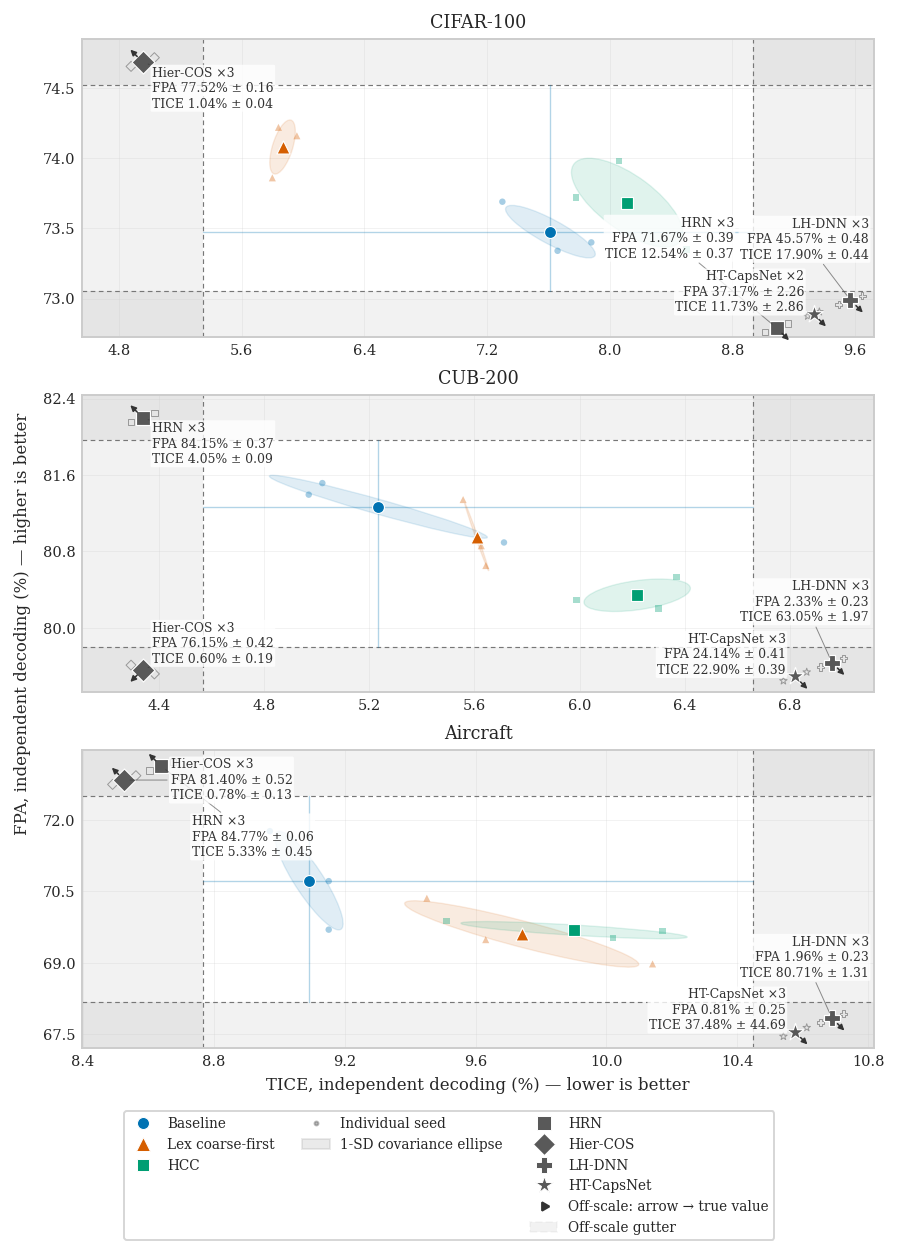

In [4]:
plot_tradeoff(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    reference_rows=reference_rows, reference_specs=REFERENCE_SPECS,
    encoding=ENCODING,
)

## Selected-Run Effects Across Hierarchy Levels

Bars are matched-seed changes in coarse, middle, and fine accuracy from the
native H-CAST baseline, in percentage points. Only seeds present in both the run
and the baseline contribute; runs without a shared seed are omitted. Each panel
has its own vertical scale, because delta ranges differ by an order of magnitude
across datasets; read the printed values, not the relative bar heights, when
comparing datasets. Because lex
disables global KL, those bars are not isolated causal effects of projection; the
HCC arm keeps global KL, so its bars do isolate HCC.

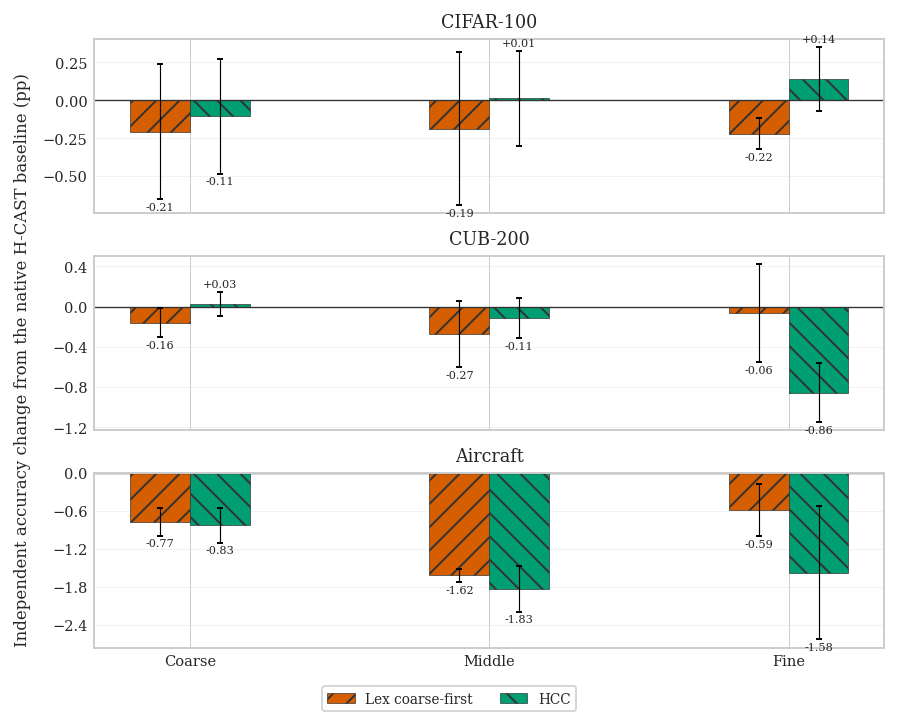

In [6]:
plot_level_accuracy_deltas(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    baseline_name='the native H-CAST baseline',
)

## Run and Pareto Summary

A run is Pareto-optimal within a dataset when no other run of the same model
family has both higher-or-equal FPA and lower-or-equal TICE, with at least one
strict improvement. Reference models are not part of this comparison. AHD and
weighted AP are reported as additional columns but do not enter the Pareto test.

In [7]:
print_summary(rows, DATASETS)


CIFAR-100
  run                       n  epoch           FPA               TICE              AHD               weighted AP       HCC diagnostics          status
  Lex coarse-first          3  98.7 ± 2.3      74.08% ± 0.19     5.87% ± 0.08      0.507 ± 0.005     78.10% ± 0.12     —                        Pareto-optimal
  HCC                       3  97.7 ± 2.5      73.68% ± 0.32     8.11% ± 0.36      0.510 ± 0.004     78.42% ± 0.15     selected α=1.00; first active=1 dominated by Lex coarse-first
  Baseline                  3  97.3 ± 2.3      73.48% ± 0.19     7.61% ± 0.29      0.511 ± 0.008     78.31% ± 0.14     —                        dominated by Lex coarse-first

CUB-200
  run                       n  epoch           FPA               TICE              AHD               weighted AP       HCC diagnostics          status
  Baseline                  3  82.7 ± 14.0     81.27% ± 0.33     5.24% ± 0.41      0.262 ± 0.002     85.59% ± 0.13     —                        Pareto-optimal
  Lex